In [1]:
# Imports
import sys, os
sys.path.append('../src')  # so it can import from your src/ folder

import requests
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
import umap
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

print("All imports successful")


All imports successful


In [2]:
# Configuration

# Change this query to test different topics
QUERY = "federated learning"

# How many papers to fetch per source
MAX_PER_SOURCE = 40

print(f"Query: '{QUERY}'")
print(f"Max per source: {MAX_PER_SOURCE}")

Query: 'federated learning'
Max per source: 40


In [3]:
# Fetch from ArXiv

def fetch_arxiv(query, max_results=50):
    base_url = "http://export.arxiv.org/api/query"
    params = {
        "search_query": f"all:{query}",
        "start": 0,
        "max_results": max_results,
        "sortBy": "relevance"
    }
    response = requests.get(base_url, params=params, timeout=15)
    ns = {'atom': 'http://www.w3.org/2005/Atom'}
    root = ET.fromstring(response.text)
    
    papers = []
    for entry in root.findall('atom:entry', ns):
        title     = entry.find('atom:title', ns)
        summary   = entry.find('atom:summary', ns)
        published = entry.find('atom:published', ns)
        link      = entry.find('atom:id', ns)
        authors   = entry.findall('atom:author', ns)
        category  = entry.findall(
            '{http://arxiv.org/schemas/atom}primary_category', ns
        )
        author_names = [
            a.find('atom:name', ns).text 
            for a in authors 
            if a.find('atom:name', ns) is not None
        ]
        papers.append({
            "title":    title.text.strip()    if title    is not None else "",
            "abstract": summary.text.strip()  if summary  is not None else "",
            "year":     published.text[:4]    if published is not None else "",
            "authors":  "; ".join(author_names[:3]),
            "url":      link.text.strip()     if link     is not None else "",
            "category": category[0].get('term') if category else "",
            "source":   "ArXiv"
        })
    
    # Filter empty
    papers = [p for p in papers if len(p['title']) > 5]
    print(f"Fetched {len(papers)} papers from ArXiv")
    return papers

def fetch_semantic_scholar(query, max_results=30):
    url = "https://api.semanticscholar.org/graph/v1/paper/search"
    params = {
        "query": query,
        "limit": max_results,
        "fields": "title,abstract,year,authors,venue,citationCount,url"
    }
    try:
        response = requests.get(url, params=params, timeout=15)
        data = response.json()
    except Exception as e:
        print(f"Semantic Scholar error: {e}")
        return []
    
    papers = []
    for p in data.get("data", []):
        authors = [a.get("name", "") for a in p.get("authors", [])[:3]]
        papers.append({
            "title":    p.get("title", ""),
            "abstract": (p.get("abstract") or "")[:1000],
            "year":     str(p.get("year", "")),
            "authors":  "; ".join(authors),
            "url":      p.get("url", ""),
            "category": p.get("venue", ""),
            "source":   "Semantic Scholar",
            "citations": p.get("citationCount", 0)
        })
    
    papers = [p for p in papers if len(p['title']) > 5]
    print(f"Fetched {len(papers)} papers from Semantic Scholar")
    return papers

# Run fetching
arxiv_papers = fetch_arxiv(QUERY, max_results=MAX_PER_SOURCE)
ss_papers    = fetch_semantic_scholar(QUERY, max_results=MAX_PER_SOURCE)

# Deduplicate
all_papers = arxiv_papers + ss_papers
seen = set()
papers = []
for p in all_papers:
    key = p['title'].lower().strip()[:60]
    if key not in seen and key != "":
        seen.add(key)
        papers.append(p)

# Sort by citation count
papers = sorted(papers, 
                key=lambda p: p.get('citations', 0) or 0, 
                reverse=True)

print(f"\nTotal unique papers: {len(papers)}")
print(f"Source breakdown:")
print(f"  ArXiv: {sum(1 for p in papers if p['source']=='ArXiv')}")
print(f"  Semantic Scholar: {sum(1 for p in papers if p['source']=='Semantic Scholar')}")

Fetched 40 papers from ArXiv
Fetched 40 papers from Semantic Scholar

Total unique papers: 79
Source breakdown:
  ArXiv: 40
  Semantic Scholar: 39


In [4]:
# Embed papers

print("Loading model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

texts = []
for p in papers:
    title    = p.get('title', '')
    abstract = p.get('abstract', '')[:500]
    venue    = p.get('category', '')
    texts.append(f"{title} {abstract} {venue}".strip())

print(f"Embedding {len(texts)} papers...")
from tqdm import tqdm


batch_size = 32
all_embeddings = []
for i in tqdm(range(0, len(texts), batch_size),
              desc="Embedding", ncols=60):
    batch = texts[i:i + batch_size]
    batch_emb = model.encode(batch, show_progress_bar=False)
    all_embeddings.append(batch_emb)

embeddings = np.vstack(all_embeddings)
embeddings = normalize(embeddings, norm='l2')
print(f"Shape: {embeddings.shape}")

Loading model...
Embedding 79 papers...


Embedding: 100%|██████████████| 3/3 [00:03<00:00,  1.24s/it]

Shape: (79, 384)


In [5]:
# UMAP reduction

import math

n = len(papers)
n_neighbors  = min(20, max(2, n - 1))
n_components = min(10, n - 1)

print(f"UMAP: {embeddings.shape[1]}-dim → {n_components}-dim")
reducer = umap.UMAP(
    n_components=n_components,
    n_neighbors=n_neighbors,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)
reduced = reducer.fit_transform(embeddings)
print(f"Reduced shape: {reduced.shape}")

UMAP: 384-dim → 10-dim
Reduced shape: (79, 10)


In [6]:
# Silhouette sweep

max_k = min(int(math.sqrt(n / 2)) + 2, 8, n - 1)
max_k = max(max_k, 2)
k_range = range(2, max_k + 1)
scores  = []

print(f"Silhouette sweep k=2 to k={max_k}...")
for k in k_range:
    labels = AgglomerativeClustering(
        n_clusters=k, linkage='ward'
    ).fit_predict(reduced)
    score = silhouette_score(reduced, labels)
    scores.append(score)
    print(f"  k={k}  silhouette={score:.4f}")

best_k     = list(k_range)[np.argmax(scores)]
best_score = max(scores)
print(f"\nBest k = {best_k}  (silhouette = {best_score:.4f})")

Silhouette sweep k=2 to k=8...
  k=2  silhouette=0.3782
  k=3  silhouette=0.3248
  k=4  silhouette=0.2712
  k=5  silhouette=0.2520
  k=6  silhouette=0.2583
  k=7  silhouette=0.2802
  k=8  silhouette=0.2688

Best k = 2  (silhouette = 0.3782)


In [7]:
# Final clustering

final_labels = AgglomerativeClustering(
    n_clusters=best_k, linkage='ward'
).fit_predict(reduced)

for i, paper in enumerate(papers):
    paper['cluster'] = int(final_labels[i])

print(f"Assigned {len(papers)} papers into {best_k} clusters")

Assigned 79 papers into 2 clusters


In [8]:
# Print cluster contents

print(f"\n{'='*70}")
print(f"CLUSTERING RESULTS FOR QUERY: '{QUERY}'")
print(f"{'='*70}\n")

for cluster_id in range(best_k):
    cluster_papers = sorted(
        [p for p in papers if p['cluster'] == cluster_id],
        key=lambda p: p.get('citations', 0) or 0,
        reverse=True
    )
    print(f"CLUSTER {cluster_id + 1}  ({len(cluster_papers)} papers)")
    print("-" * 60)
    for p in cluster_papers[:5]:
        cites = p.get('citations', 0) or 0
        print(f"  • [{cites:>4} citations] {p['title'][:65]}")
    if len(cluster_papers) > 5:
        print(f"  ... and {len(cluster_papers) - 5} more")
    print()


CLUSTERING RESULTS FOR QUERY: 'federated learning'

CLUSTER 1  (54 papers)
------------------------------------------------------------
  • [8037 citations] Advances and Open Problems in Federated Learning
  • [5665 citations] Federated Learning: Challenges, Methods, and Future Directions
  • [5266 citations] Federated Learning: Strategies for Improving Communication Effici
  • [3693 citations] SCAFFOLD: Stochastic Controlled Averaging for Federated Learning
  • [3127 citations] Federated Learning with Non-IID Data
  ... and 49 more

CLUSTER 2  (25 papers)
------------------------------------------------------------
  • [2395 citations] How To Backdoor Federated Learning
  • [2062 citations] Federated Learning With Differential Privacy: Algorithms and Perf
  • [1730 citations] Comprehensive Privacy Analysis of Deep Learning: Passive and Acti
  • [1577 citations] Differentially Private Federated Learning: A Client Level Perspec
  • [1552 citations] Inverting Gradients - How easy is it 

In [9]:
# Export to Excel

import io
from openpyxl.styles import Font, PatternFill, Alignment

rows = []
for p in papers:
    rows.append({
        "Cluster No.":   p['cluster'] + 1,
        "Title":         p['title'],
        "Year":          p.get('year', ''),
        "Authors":       p.get('authors', ''),
        "Source":        p.get('source', ''),
        "Category/Venue": p.get('category', ''),
        "Citations":     p.get('citations', 'N/A'),
        "Abstract":      p.get('abstract', '')[:300],
        "URL":           p.get('url', '')
    })

df = pd.DataFrame(rows).sort_values(
    ['Cluster No.', 'Citations'],
    ascending=[True, False]
)

filename = f"clustered_papers_{QUERY.replace(' ', '_')}.xlsx"

cluster_colors = [
    "FFFFFF", "EBF5FB", "FEF9E7", "EAFAF1",
    "FDEDEC", "F4ECF7", "FDF2E9", "E8F8F5"
]

with pd.ExcelWriter(filename, engine='openpyxl') as writer:
    df.to_excel(writer, index=False, sheet_name='Clustered Papers')
    ws = writer.sheets['Clustered Papers']
    
    # Header
    for cell in ws[1]:
        cell.font      = Font(bold=True, color="FFFFFF")
        cell.fill      = PatternFill("solid", fgColor="2E75B6")
        cell.alignment = Alignment(
            horizontal='center', vertical='center'
        )
    
    # Column widths
    widths = {
        'A': 10, 'B': 55, 'C': 8,  'D': 30,
        'E': 18, 'F': 20, 'G': 10, 'H': 50, 'I': 45
    }
    for col, width in widths.items():
        ws.column_dimensions[col].width = width
    
    # Row colouring by cluster
    for row in ws.iter_rows(min_row=2):
        cnum = row[0].value
        if cnum and isinstance(cnum, int):
            color = cluster_colors[(cnum - 1) % len(cluster_colors)]
            for cell in row:
                cell.fill      = PatternFill("solid", fgColor=color)
                cell.alignment = Alignment(
                    wrap_text=True, vertical='top'
                )
    
    # Freeze header row
    ws.freeze_panes = 'A2'
    
    # Add a summary sheet
    summary_rows = []
    for cid in range(best_k):
        cp = [p for p in papers if p['cluster'] == cid]
        top_paper = max(cp, key=lambda p: p.get('citations',0) or 0)
        summary_rows.append({
            "Cluster":       cid + 1,
            "Paper Count":   len(cp),
            "Top Paper":     top_paper['title'][:60],
            "Top Citations": top_paper.get('citations', 0),
            "Year Range":    f"{min(p['year'] for p in cp if p.get('year','').isdigit() or '0')} – "
                            f"{max(p['year'] for p in cp if p.get('year','').isdigit() or '0')}"
        })
    
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_excel(
        writer, index=False, sheet_name='Cluster Summary'
    )
    ws2 = writer.sheets['Cluster Summary']
    for cell in ws2[1]:
        cell.font = Font(bold=True, color="FFFFFF")
        cell.fill = PatternFill("solid", fgColor="2E75B6")

print(f"Saved: {filename}")
print(f"Sheets: 'Clustered Papers' and 'Cluster Summary'")
print(f"Open in Excel for screenshot.")

Saved: clustered_papers_federated_learning.xlsx
Sheets: 'Clustered Papers' and 'Cluster Summary'
Open in Excel for screenshot.


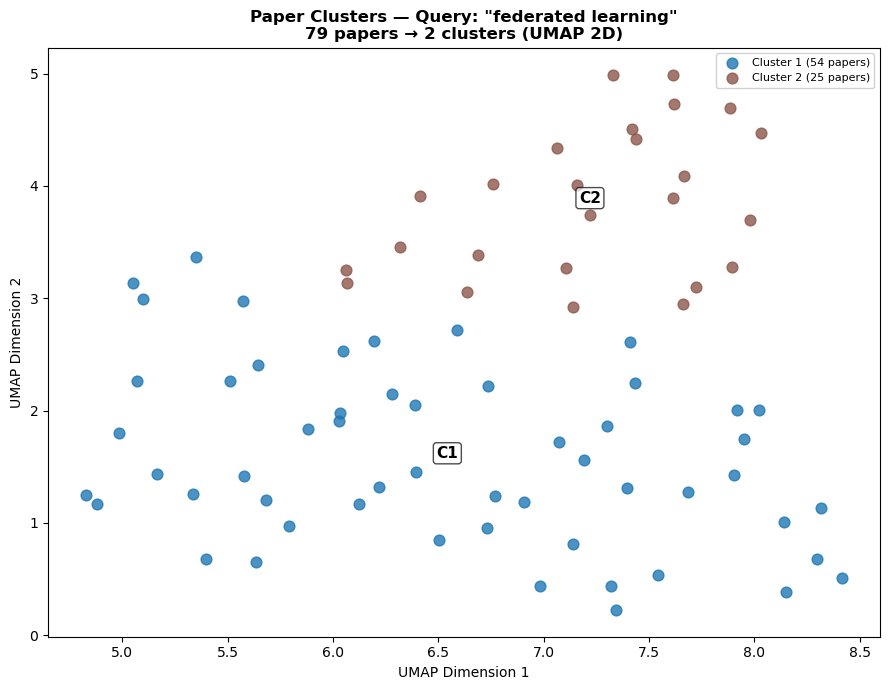

Saved: paper_clusters_federated_learning.png


In [10]:
# 2D visualisation

reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=min(15, n - 1),
    min_dist=0.1,
    metric='cosine',
    random_state=42
)
emb_2d = reducer_2d.fit_transform(embeddings)

colors_list = [cm.tab10(i / best_k) for i in range(best_k)]

plt.figure(figsize=(9, 7))
for cid in range(best_k):
    mask = final_labels == cid
    plt.scatter(
        emb_2d[mask, 0], emb_2d[mask, 1],
        c=[colors_list[cid]], s=60, alpha=0.8,
        label=f'Cluster {cid + 1} ({mask.sum()} papers)'
    )
    cx = emb_2d[mask, 0].mean()
    cy = emb_2d[mask, 1].mean()
    plt.annotate(
        f'C{cid + 1}', (cx, cy),
        fontsize=11, fontweight='bold', ha='center',
        bbox=dict(
            boxstyle='round,pad=0.2',
            facecolor='white', alpha=0.7
        )
    )

plt.legend(fontsize=8, loc='best', framealpha=0.9)
plt.title(
    f'Paper Clusters — Query: "{QUERY}"\n'
    f'{len(papers)} papers → {best_k} clusters (UMAP 2D)',
    fontsize=12, fontweight='bold'
)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.tight_layout()

img_filename = f'paper_clusters_{QUERY.replace(" ", "_")}.png'
plt.savefig(img_filename, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {img_filename}")